<a href="https://colab.research.google.com/github/Sancheuz123/KSVD/blob/main/%D0%9B%D0%A0_4_%D0%93%D0%90%D0%B9%D0%B2%D0%BE%D1%80%D0%BE%D0%BD%D1%81%D1%8C%D0%BA%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
uploaded = files.upload()

Saving Museum_Visitors.csv to Museum_Visitors.csv


In [10]:
df = pd.read_csv('Museum_Visitors.csv', encoding= 'latin1')
df

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
80,09/01/2020 12:00:00 AM,0,0,0,0.0,0,NaN,0.0,0.0,NaN,0.0,NaN
81,10/01/2020 12:00:00 AM,0,0,0,0.0,0,NaN,0.0,0.0,NaN,0.0,2533.0
82,11/01/2020 12:00:00 AM,0,0,0,0.0,0,NaN,0.0,0.0,NaN,0.0,3801.0
83,12/01/2020 12:00:00 AM,0,0,0,0.0,0,NaN,0.0,0.0,NaN,0.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Month                                  85 non-null     object 
 1   America Tropical Interpretive Center   85 non-null     int64  
 2   Avila Adobe                            85 non-null     int64  
 3   Chinese American Museum                85 non-null     int64  
 4   Gateway to Nature Center               32 non-null     float64
 5   Firehouse Museum                       85 non-null     int64  
 6   Hellman Quon                           26 non-null     float64
 7   IAMLA                                  54 non-null     float64
 8   Pico House                             83 non-null     float64
 9   Visitor Center/ El Tranquilo Gallery   45 non-null     float64
 10  Museum of Social Justice               37 non-null     float64
 11  Biscailu

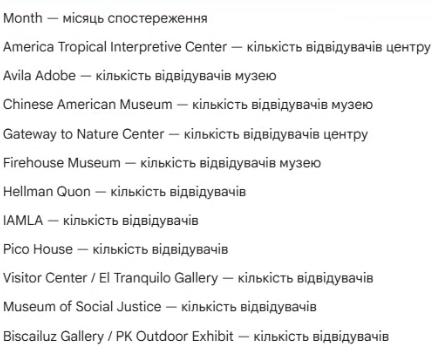

In [12]:
df.head()

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


In [13]:
df.shape

(85, 12)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.isnull().sum()

,0
Month,0
America Tropical Interpretive Center,0
Avila Adobe,0
Chinese American Museum,0
Gateway to Nature Center,53
Firehouse Museum,0
Hellman Quon,59
IAMLA,31
Pico House,2
Visitor Center/ El Tranquilo Gallery,40


In [16]:
df = df.fillna(df.mean(numeric_only=True), axis=0)

In [17]:
df.isnull().sum()

,0
Month,0
America Tropical Interpretive Center,0
Avila Adobe,0
Chinese American Museum,0
Gateway to Nature Center,0
Firehouse Museum,0
Hellman Quon,0
IAMLA,0
Pico House,0
Visitor Center/ El Tranquilo Gallery,0


In [18]:
df.head()

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,1247.375,4486,0.0,882.611111,2204.0,2961.0,2125.972973,1088.615385
1,02/01/2014 12:00:00 AM,5029,18976,1785,1247.375,4172,0.0,882.611111,1330.0,2276.0,2125.972973,1088.615385
2,03/01/2014 12:00:00 AM,8129,25231,3229,1247.375,7082,70.0,882.611111,4320.0,3116.0,2125.972973,1088.615385
3,04/01/2014 12:00:00 AM,2824,26989,2129,1247.375,6756,250.0,882.611111,3277.0,2808.0,2125.972973,1088.615385
4,05/01/2014 12:00:00 AM,10694,36883,3676,1247.375,10858,135.0,882.611111,4122.0,3987.0,2125.972973,1088.615385


In [19]:
df.describe()

,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,5637.694118,19904.952941,2359.117647,1247.375000,5286.776471,353.461538,882.611111,1329.710843,2634.800000,2125.972973,1088.615385
std,3277.453044,9495.340548,1360.427221,736.364942,6591.535926,243.882008,402.879854,1810.572631,1487.684023,1279.746780,447.156828
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3891.000000,17056.000000,1785.000000,1247.375000,3858.000000,353.461538,863.000000,185.000000,2634.800000,2125.972973,1038.000000
50%,5705.000000,20815.000000,2371.000000,1247.375000,4613.000000,353.461538,882.611111,610.000000,2634.800000,2125.972973,1088.615385
75%,6955.000000,25234.000000,2808.000000,1247.375000,5406.000000,353.461538,1088.000000,1550.000000,2771.000000,2125.972973,1088.615385
max,13490.000000,41242.000000,7702.000000,4227.000000,61192.000000,2000.000000,1883.000000,9312.000000,13750.000000,10740.000000,3801.000000


In [20]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('/', '_').str.replace('_', '_').str.strip()
df.columns

Index(['month', 'america_tropical_interpretive_center', 'avila_adobe',
       'chinese_american_museum', 'gateway_to_nature_center',
       'firehouse_museum', 'hellman_quon', 'iamla', 'pico_house_',
       'visitor_center__el_tranquilo_gallery', 'museum_of_social_justice',
       'biscailuz_gallery__pk_outdoor_exhibit'],
      dtype='object')

In [21]:
df.tail()

,month,america_tropical_interpretive_center,avila_adobe,chinese_american_museum,gateway_to_nature_center,firehouse_museum,hellman_quon,iamla,pico_house_,visitor_center__el_tranquilo_gallery,museum_of_social_justice,biscailuz_gallery__pk_outdoor_exhibit
80,09/01/2020 12:00:00 AM,0,0,0,0.0,0,353.461538,0.0,0.0,2634.8,0.0,1088.615385
81,10/01/2020 12:00:00 AM,0,0,0,0.0,0,353.461538,0.0,0.0,2634.8,0.0,2533.000000
82,11/01/2020 12:00:00 AM,0,0,0,0.0,0,353.461538,0.0,0.0,2634.8,0.0,3801.000000
83,12/01/2020 12:00:00 AM,0,0,0,0.0,0,353.461538,0.0,0.0,2634.8,0.0,0.000000
84,01/01/2021 12:00:00 AM,0,0,0,0.0,0,353.461538,0.0,0.0,2634.8,0.0,0.000000


In [25]:
df['month'] = pd.to_datetime(df['month'], format='%m/%d/%Y %I:%M:%S %p')

df_2018 = df[df['month'].dt.year == 2018]

min_visitors = df_2018.iloc[:, 1:].min()
max_visitors = df_2018.iloc[:, 1:].max()
result = pd.DataFrame({'min': min_visitors, 'max': max_visitors})

result

,min,max
america_tropical_interpretive_center,3180.000000,5837.000000
avila_adobe,14718.000000,25173.000000
chinese_american_museum,2078.000000,4960.000000
gateway_to_nature_center,1247.375000,1247.375000
firehouse_museum,3306.000000,8013.000000
hellman_quon,353.461538,353.461538
iamla,965.000000,1601.000000
pico_house_,185.000000,2140.000000
visitor_center__el_tranquilo_gallery,2634.800000,2634.800000
museum_of_social_justice,2332.000000,3686.000000


In [26]:
average_visitors = df.iloc[:, 1:].mean()
average_visitors

,0
america_tropical_interpretive_center,5637.694118
avila_adobe,19904.952941
chinese_american_museum,2359.117647
gateway_to_nature_center,1247.375000
firehouse_museum,5286.776471
hellman_quon,353.461538
iamla,882.611111
pico_house_,1329.710843
visitor_center__el_tranquilo_gallery,2634.800000
museum_of_social_justice,2125.972973


In [28]:
df_2015 = df.loc[df['month'].dt.year == 2015].copy()

df_2015['total_visitors'] = df_2015.iloc[:, 1:].sum(axis=1)

min_row = df_2015.loc[df_2015['total_visitors'].idxmin()]
max_row = df_2015.loc[df_2015['total_visitors'].idxmax()]

min_month = min_row['month'].strftime('%B')
max_month = max_row['month'].strftime('%B')

print(f'Найнижча відвідуваність у {min_month}')
print(f'Найвища відвідуваність у {max_month}')

Найнижча відвідуваність у February
Найвища відвідуваність у May


In [29]:
df_2015.head()

,month,america_tropical_interpretive_center,avila_adobe,chinese_american_museum,gateway_to_nature_center,firehouse_museum,hellman_quon,iamla,pico_house_,visitor_center__el_tranquilo_gallery,museum_of_social_justice,biscailuz_gallery__pk_outdoor_exhibit,total_visitors
12,2015-01-01,6250,20438,1823,1247.375,3858,75.0,882.611111,200.0,2082.0,2125.972973,1088.615385,40070.574469
13,2015-02-01,5907,15578,1558,1247.375,3742,160.0,882.611111,1075.0,2751.0,2125.972973,1088.615385,36115.574469
14,2015-03-01,9884,21297,2336,1247.375,5390,325.0,882.611111,3445.0,2748.0,2125.972973,1088.615385,50769.574469
15,2015-04-01,7254,26670,3057,1247.375,7000,2000.0,882.611111,3292.0,3408.0,2125.972973,1088.615385,58025.574469
16,2015-05-01,13207,34383,4009,1247.375,12528,475.0,882.611111,5042.0,3785.0,2125.972973,1088.615385,78773.574469


In [30]:
df_2018 = df[df['month'].dt.year == 2018].copy()

df_2018['month_num'] = df_2018['month'].dt.month

summer = df_2018[df_2018['month_num'].isin([6, 7, 8])]['avila_adobe'].sum()

winter = df_2018[df_2018['month_num'].isin([1, 2, 12])]['avila_adobe'].sum()

print(f" Літом відвідали: {summer} людей")
print(f" Зимою відвідали: {winter} людей")

 Літом відвідали: 66122 людей
 Зимою відвідали: 48705 людей


In [31]:
df.corr()

,month,america_tropical_interpretive_center,avila_adobe,chinese_american_museum,gateway_to_nature_center,firehouse_museum,hellman_quon,iamla,pico_house_,visitor_center__el_tranquilo_gallery,museum_of_social_justice,biscailuz_gallery__pk_outdoor_exhibit
month,1.000000,-0.781557,-0.738084,-0.315742,-3.319433e-01,-0.371774,2.091013e-02,-2.161637e-01,-0.475915,-1.395551e-02,-1.504719e-01,7.475819e-02
america_tropical_interpretive_center,-0.781557,1.000000,0.854877,0.540915,4.754155e-01,0.279719,-3.002331e-02,4.267715e-01,0.495783,1.045570e-01,2.860157e-01,-5.913842e-02
avila_adobe,-0.738084,0.854877,1.000000,0.591643,5.994894e-01,0.415099,2.828129e-02,6.129649e-01,0.440687,7.427750e-02,3.818376e-01,-1.054805e-01
chinese_american_museum,-0.315742,0.540915,0.591643,1.000000,5.956485e-01,0.164809,2.658100e-02,6.021707e-01,0.150424,1.408652e-01,4.223186e-01,-4.708062e-02
gateway_to_nature_center,-0.331943,0.475416,0.599489,0.595648,1.000000e+00,0.194937,3.850117e-17,5.707920e-01,0.055837,-2.753450e-02,3.761572e-01,-1.150013e-01
firehouse_museum,-0.371774,0.279719,0.415099,0.164809,1.949374e-01,1.000000,3.697758e-01,2.161862e-01,0.153608,-1.203960e-01,1.370450e-01,-2.544659e-02
hellman_quon,0.020910,-0.030023,0.028281,0.026581,3.850117e-17,0.369776,1.000000e+00,1.770881e-17,0.171372,1.156224e-01,1.269785e-17,-9.213333e-18
iamla,-0.216164,0.426772,0.612965,0.602171,5.707920e-01,0.216186,1.770881e-17,1.000000e+00,0.117421,2.140129e-02,6.777008e-01,-4.802304e-02
pico_house_,-0.475915,0.495783,0.440687,0.150424,5.583673e-02,0.153608,1.713717e-01,1.174211e-01,1.000000,4.509112e-01,9.413240e-02,-4.705054e-02
visitor_center__el_tranquilo_gallery,-0.013956,0.104557,0.074277,0.140865,-2.753450e-02,-0.120396,1.156224e-01,2.140129e-02,0.450911,1.000000e+00,-3.330576e-17,4.536785e-02


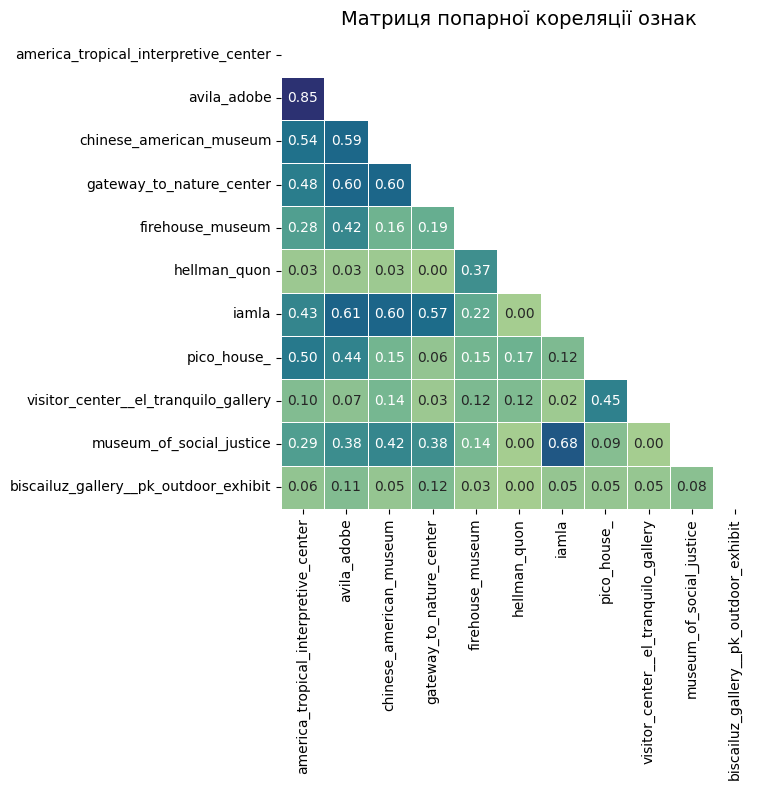

In [35]:
mtx = df.corr (numeric_only=True).abs()
fig, ax = plt.subplots (figsize=(8, 8))
sns.heatmap(
mtx,
cmap='crest',
annot=True,
fmt=".2f",
linewidths=0.5,
mask=np.triu(np.ones_like (mtx, dtype=bool)),
square=True,
cbar=False,
ax=ax
)
plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()


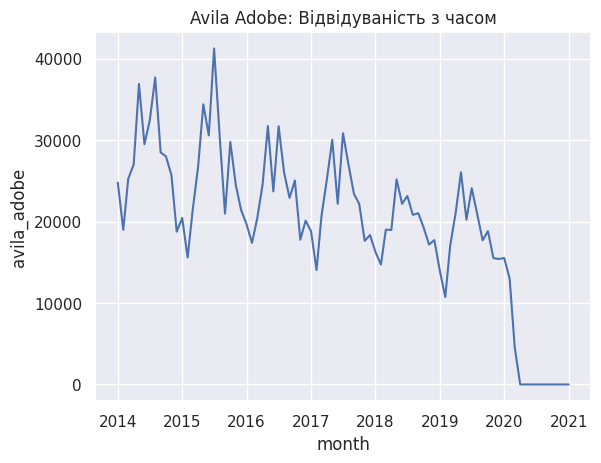

In [36]:
sns.set_theme (style="darkgrid")
sns.lineplot(data=df, x='month', y='avila_adobe')
plt.title('Avila Adobe: Відвідуваність з часом')
plt.show()

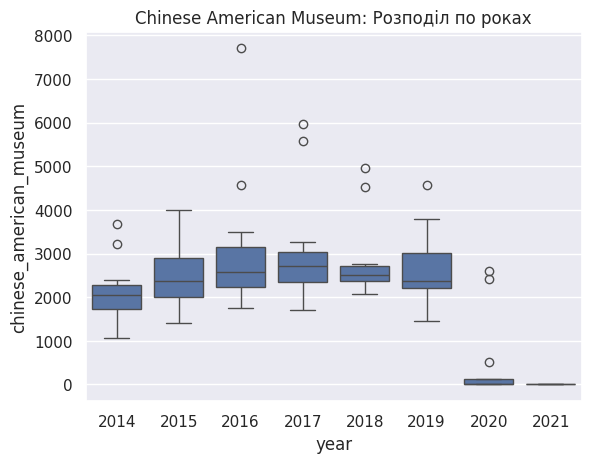

In [37]:
df['year'] = df['month'].dt.year
sns.boxplot(data=df, x='year', y='chinese_american_museum')
plt.title('Chinese American Museum: Розподіл по роках')
plt.show()

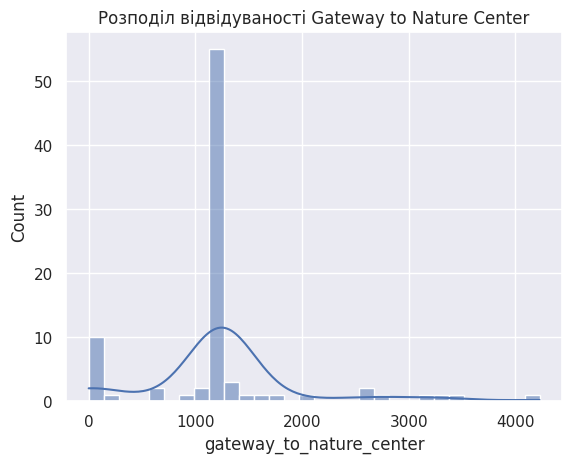

In [38]:
sns.histplot(df['gateway_to_nature_center'], bins=30, kde=True)
plt.title('Розподіл відвідуваності Gateway to Nature Center')
plt.show()

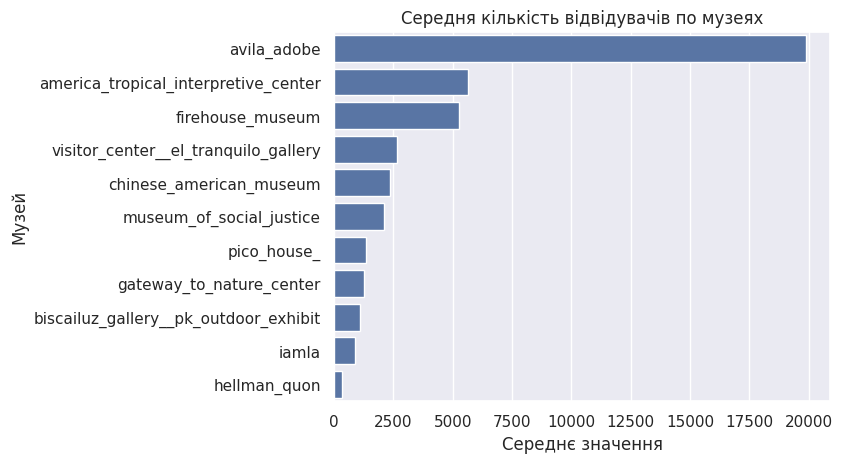

In [39]:
avg_visitors = df.drop(columns=['month', 'year']).mean().sort_values (ascending=False)
sns.barplot(x=avg_visitors.values, y=avg_visitors.index)
plt.title('Cередня кількість відвідувачів по музеях')
plt.xlabel('Середнє значення')
plt.ylabel('Музей')
plt.show()